# Q11. Why are the partial-epoch LoRA scores limited?

Investigate the completed run without modifying its fitted checkpoint or original notebook. Use a uniform, seeded sample of 2,048 frozen validation variants for two inference passes: trained adapters and zero adapter outputs with the jointly fitted head held fixed. This user-authorized speed adjustment leaves the original 17,927-variant benchmark unchanged. Previously completed seeded probes use 1,024 already-seen and 1,024 unvisited training rows; their source, checkpoint identity, checksums and membership are verified before reuse. These are diagnostic samples, not full-cohort results. [Implementation](src/q11_lora_diagnostics.py) · [Original experiment](Q11-evo2-lora.ipynb).

In [1]:
from src import q11_lora_diagnostics as diagnostic

## Checks and interventions

Verify the original source/checkpoint/prediction checksums, freeze the seed-42 sample keys before inference, and reproduce every saved score on that sample. Decompose the linear head into reference and allele-difference contributions. Measure raw and relative difference magnitudes before the per-example RMS normalization. Larger magnitude is predeclared as the positive direction; no validation-selected sign flip. Restore adapter weights after the intervention and verify unchanged original backbone tensors. No new parameters or thresholds are fitted. Expect about 6–8 minutes on the prepared H100.

In [2]:
report = diagnostic.run()

Seeded 2,048-variant diagnostic progress: results/q11/diagnostics/lora_quality/run.log


## Results

AP is average precision over the ranking, distinct from precision at a chosen threshold. The classifier uses balanced training class weights, so its raw sigmoid is not established as a calibrated risk. Paired differences use 1,000 whole-component bootstrap draws, seed 42. Branch and magnitude scores are post-hoc diagnostics and do not provide an independent model-selection holdout.

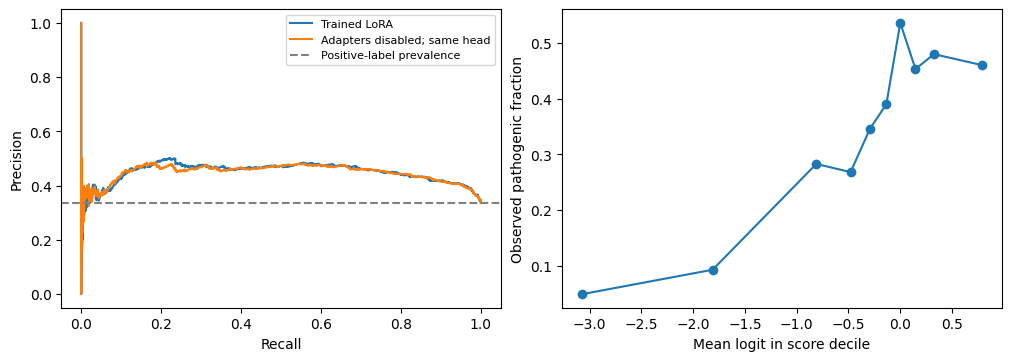

In [3]:
diagnostic.show(report)

## Interpretation

The original run used 52.4% of training variants, 512-base single-strand paired inputs and a randomly initialized joint head, without fitting a frozen-head baseline. Several choices differ from Q2. [Arc recommends intermediate embeddings over final embeddings](https://github.com/ArcInstitute/evo2#embeddings); that supports testing the feature layer, but does not prove the cause of this run’s gap. A head-only control is also part of [NVIDIA’s Evo2 LoRA example](https://docs.nvidia.com/bionemo-recipes/latest/main/recipes/recipes/evo2_megatron/index.html#lora-fine-tuning).

In [4]:
diagnostic.conclude(report)

**Conclusion.** The original full-validation AUROC/AP remain **0.693/0.487**. On the fixed 2,048-variant diagnostic sample, trained AUROC/AP are **0.684/0.449**, reproducing saved scores. Disabling adapters with the trained head fixed gives **0.682/0.448** (trained-minus-disabled AUROC +0.002, 95% component-bootstrap interval [-0.004, +0.008]). The reference and difference head contributions have AUROC **0.479** and **0.706**, respectively. Larger raw allele-difference magnitude scores AUROC **0.777**; the classifier's per-example normalization discards this magnitude. At logit zero, precision/recall are **0.470/0.494**; AP is a ranking summary, with positive prevalence **0.336**. Post-hoc development diagnostics on a fixed seeded sample of 2,048 validation variants; these do not replace the original 17,927-variant benchmark. Disabled adapters retain the jointly trained head; this is not a fitted frozen-head baseline. Previously completed training probes are verified and reused from the archived full-pass attempt. Training probes are diagnostic samples, not full-cohort performance estimates. The 512-base representation, single strand, normalization, head and backend all differ from Q2; the Q2–Q11 gap cannot be assigned to LoRA alone.